In [1]:
import pandas as pd
import numpy as np 

import sys
from langchain_community.vectorstores import FAISS
#from langchain.vectorstores import FAISS

from langchain_huggingface import HuggingFaceEmbeddings

#from langchain.embeddings import HuggingFaceEmbeddings




#from mistral import MistralClient
#from mistralai import Mistral
from mistralai.client import MistralClient



import requests

e:\Apps\python 3.11\openagenda-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#!pip uninstall mistralai -y
#!pip install mistralai==0.4.2

from mistralai import Mistral

client = Mistral(api_key="YOUR_API_KEY")

response = client.chat.complete(
    model="mistral-small-latest",
    messages=[
        {"role": "user", "content": "Hello"}
    ]
)

print(response.choices[0].message.content)

In [3]:
import mistralai
print(mistralai)
print(mistralai.__file__)

<module 'mistralai' from 'e:\\Apps\\python 3.11\\openagenda-env\\Lib\\site-packages\\mistralai\\__init__.py'>
e:\Apps\python 3.11\openagenda-env\Lib\site-packages\mistralai\__init__.py


In [4]:
pip show mistralai

Name: mistralai
Version: 0.4.2
Summary: 
Home-page: 
Author: Bam4d
Author-email: bam4d@mistral.ai
License: Apache 2.0 License
Location: e:\Apps\python 3.11\openagenda-env\Lib\site-packages
Requires: httpx, orjson, pydantic
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [5]:
print(sys.executable)
print(sys.version)

e:\Apps\python 3.11\openagenda-env\Scripts\python.exe
3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]


In [6]:
import sys
print(sys.executable)

e:\Apps\python 3.11\openagenda-env\Scripts\python.exe


In [7]:
from datetime import datetime, timedelta
import math
from transformers import AutoTokenizer, AutoModel
import torch

clé 4d94edccd1cb4b268096d10704020532

In [8]:
#curl -H "key: 4d94edccd1cb4b268096d10704020532" https://api.openagenda.com/v2/agendas

In [9]:
#r = requests.get('https://api.openagenda.com/v2/agendas')
#x = r.json()
#df = pd.DataFrame(x['agenda'])
#df

# paramètres API
agenda_uid = "UID_DE_TON_AGENDA"
api_key = "4d94edccd1cb4b268096d10704020532"

url = f"https://api.openagenda.com/v2/agendas/{agenda_uid}/events"

params = {
    "key": api_key,
    "size": 100   # nombre d'événements récupérés
}

response = requests.get(url, params=params)
data = response.json()

# récupérer la liste des événements
events = data["events"]

# transformer en DataFrame
df = pd.json_normalize(events)

print(df.head())

"https://api.openagenda.com/v2/agendas/47052338/events"


agenda_uid = "47052338"
api_key = "4d94edccd1cb4b268096d10704020532"

# période : 1 an avant aujourd'hui
today = datetime.today()
start_date = (today - timedelta(days=365)).strftime("%Y-%m-%d")

url = f"https://api.openagenda.com/v2/agendas/{agenda_uid}/events"

events_all = []
page = 1

while True:
    
    params = {
        "key": api_key,
        "size": 100,
        "page": page,
        "timings[from]": start_date,   #1 an
    }

    r = requests.get(url, params=params)
    data = r.json()
    
    events = data.get("events", [])
    
    if not events:
        break
        
    events_all.extend(events)
    page += 1

# création dataframe
df = pd.json_normalize(events_all)

# sélection colonnes utiles
df = df[[
    "uid",
    "title.fr",
    "location.name",
    "location.city",
    "firstTiming.begin",
    "firstTiming.end",
    "keywords"
]]

# conversion dates
df["firstTiming.begin"] = pd.to_datetime(df["firstTiming.begin"])
df["firstTiming.end"] = pd.to_datetime(df["firstTiming.end"])

print(df.head())

PAGINATION BOUCLES

url = "https://api.openagenda.com/v2/agendas/47052338/events"
key = "4d94edccd1cb4b268096d10704020532"

events_all = []
page = 1

while True:

    params = {
        "key": key,
        "size": 100,
        "page": page
    }

    r = requests.get(url, params=params)
    data = r.json()

    events = data.get("events", [])

    if not events:
        break

    events_all.extend(events)
    page += 1

df = pd.json_normalize(events_all)

print(len(df))
print(df.head())

url = "https://api.openagenda.com/v2/agendas/47052338/events"

today = datetime.today()

date_from = (today - timedelta(days=365)).strftime("%Y-%m-%d")
date_to = (today + timedelta(days=365)).strftime("%Y-%m-%d")

events_all = []
page = 1

while True:

    params = {
        "key": "4d94edccd1cb4b268096d10704020532",
        "timings[from]": date_from,
        "timings[to]": date_to,
        "size": 100,
        "page": page,
        "sort": "timings.begin"
    }

    response = requests.get(url, params=params)
    data = response.json()

    events = data.get("events", [])

    if not events:
        break

    events_all.extend(events)
    page += 1


df = pd.json_normalize(events_all)

df["firstTiming.begin"] = pd.to_datetime(df["firstTiming.begin"])
df["firstTiming.end"] = pd.to_datetime(df["firstTiming.end"])

print(df.head())
print(df["firstTiming.begin"].min(), df["firstTiming.begin"].max())

In [10]:

url = "https://api.openagenda.com/v2/agendas/47052338/events"

today = datetime.today()
date_from = (today - timedelta(days=365)).strftime("%Y-%m-%d")
date_to = (today + timedelta(days=365)).strftime("%Y-%m-%d")

size = 100
page = 1
events_all = []

params = {
    "key": "4d94edccd1cb4b268096d10704020532",
    "timings[from]": date_from,
    "timings[to]": date_to,
    "size": size,
    "page": page
}

response = requests.get(url, params=params)
data = response.json()

events_all.extend(data["events"])

# calcul du nombre total de pages
total = data["total"]
total_pages = math.ceil(total / size)

# récupérer les autres pages
for page in range(2, total_pages + 1):

    params["page"] = page
    response = requests.get(url, params=params)
    data = response.json()

    events_all.extend(data["events"])

# dataframe
events = data["events"]
df = pd.json_normalize(events_all)

#f["firstTiming.begin"] = pd.to_datetime(df["firstTiming.begin"])
#df["firstTiming.end"] = pd.to_datetime(df["firstTiming.end"])

print(df.head())
print(len(df))

   featured  attendanceMode imageCredits onlineAccessLink       uid  \
0     False               1         None             None  80262476   
1     False               1         None             None  56513581   
2     False               1         None             None  22276968   
3     False               1         None             None  88012351   
4     False               1         None             None     84445   

                            slug  status  \
0    hollie-cook-la-yegros-siska       1   
1          forever-pavot-yin-yin       1   
2  heavy-lungs-body-horror-chest       1   
3       blu-samu-ades-the-planet       1   
4     black-sea-dahu-1ere-partie       1   

                                    image.filename  image.size.width  \
0  0fb33e08983845debeb77b405973d8e4.base.image.jpg               700   
1  1f6b9ae6995e44b7a560d74159e0bd5e.base.image.jpg               700   
2  99b12b07d2c346beb79e829ec02c874b.base.image.jpg               700   
3  f3ccfe2ee97a4aabb

In [11]:
df["description.fr"].info()

<class 'pandas.Series'>
RangeIndex: 99 entries, 0 to 98
Series name: description.fr
Non-Null Count  Dtype
--------------  -----
99 non-null     str  
dtypes: str(1)
memory usage: 924.0 bytes


In [12]:
df

,featured,attendanceMode,imageCredits,onlineAccessLink,uid,slug,status,image.filename,image.size.width,image.size.height,...,firstTiming.begin,location.address,location.city,location.latitude,location.name,location.longitude,nextTiming.begin,nextTiming.end,dateRange.nl,nextTiming
0,False,1,None,None,80262476,hollie-cook-la-yegros-siska,1,0fb33e08983845debeb77b405973d8e4.base.image.jpg,700,700,...,2026-04-03T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,2026-04-03T20:00:00+02:00,2026-04-04T01:00:00+02:00,NaN,NaN
1,False,1,None,None,56513581,forever-pavot-yin-yin,1,1f6b9ae6995e44b7a560d74159e0bd5e.base.image.jpg,700,700,...,2026-04-09T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,2026-04-09T20:00:00+02:00,2026-04-10T01:00:00+02:00,NaN,NaN
2,False,1,None,None,22276968,heavy-lungs-body-horror-chest,1,99b12b07d2c346beb79e829ec02c874b.base.image.jpg,700,700,...,2026-04-11T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,2026-04-11T20:00:00+02:00,2026-04-12T01:00:00+02:00,NaN,NaN
3,False,1,None,None,88012351,blu-samu-ades-the-planet,1,f3ccfe2ee97a4aabbb8914cb21bdec8b.base.image.jpg,700,700,...,2026-04-24T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,2026-04-24T20:00:00+02:00,2026-04-25T01:00:00+02:00,NaN,NaN
4,False,1,None,None,84445,black-sea-dahu-1ere-partie,1,2aae0e2b5a044ef7bc0e339040878834.base.image.jpg,700,700,...,2026-04-30T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,2026-04-30T20:00:00+02:00,2026-05-01T01:00:00+02:00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,False,1,None,None,96654035,idles,1,fe9755ed27ba48e0aaefc2d6af8d293a.base.image.jpg,700,700,...,2025-06-04T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,NaN,NaN,NaN,NaN
95,False,1,None,None,86219516,youssoupha-joanne-radao-base,1,4e7648b57ed34bb192d09f7c0056a0b8.base.image.jpg,700,700,...,2025-05-23T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,NaN,NaN,NaN,NaN
96,False,1,None,None,42832059,coilguns-going-off-treaks,1,3d51ca0fe6a941ccb655b8015e51619e.base.image.jpg,700,700,...,2025-05-20T20:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,NaN,NaN,NaN,NaN
97,False,1,None,None,78028280,lodyssee-musicale-des-40-ans,1,f316fd9d45c347d4a747c39401bff7fb.base.image.jpg,700,700,...,2025-05-17T18:00:00.000+02:00,111 Boulevard Emile Delmas 17000 La Rochelle,La Rochelle,46.160216,La Sirène,-1.215559,NaN,NaN,NaN,NaN


In [13]:
df = pd.json_normalize(events)

df = df[[
    "uid",
    "title.fr",
    "description.fr",
    "location.name",
    "location.city",
    "firstTiming.begin",
    "firstTiming.end",
    "nextTiming.begin",
    "nextTiming.end",
    "lastTiming.begin"	
]]

print(df.head())

        uid                            title.fr     description.fr  \
0  80262476     HOLLIE COOK + LA YEGROS + SISKA        Dub, Reggae   
1  56513581             FOREVER PAVOT + YIN YIN  Pop, Psyché, Rock   
2  22276968  HEAVY LUNGS + BODY HORROR + CHEST.   Indie, Post-Punk   
3  88012351          BLU SAMU + ADÉS THE PLANET       Chanson, Rap   
4     84445              BLACK SEA DAHU + MEL D          Folk, Pop   

  location.name location.city              firstTiming.begin  \
0     La Sirène   La Rochelle  2026-04-03T20:00:00.000+02:00   
1     La Sirène   La Rochelle  2026-04-09T20:00:00.000+02:00   
2     La Sirène   La Rochelle  2026-04-11T20:00:00.000+02:00   
3     La Sirène   La Rochelle  2026-04-24T20:00:00.000+02:00   
4     La Sirène   La Rochelle  2026-04-30T20:00:00.000+02:00   

                 firstTiming.end           nextTiming.begin  \
0  2026-04-04T01:00:00.000+02:00  2026-04-03T20:00:00+02:00   
1  2026-04-10T01:00:00.000+02:00  2026-04-09T20:00:00+02:00   
2  20

In [14]:
df["firstTiming.begin"] = pd.to_datetime(df["firstTiming.begin"], utc=True)
df["firstTiming.end"] = pd.to_datetime(df["firstTiming.end"], utc=True)

In [15]:
df["nextTiming.begin"] = pd.to_datetime(df["nextTiming.begin"], utc=True)
df["nextTiming.end"] = pd.to_datetime(df["nextTiming.end"], utc=True)
df["lastTiming.begin"] = pd.to_datetime(df["nextTiming.begin"], utc=True)

In [16]:
df

,uid,title.fr,description.fr,location.name,location.city,firstTiming.begin,firstTiming.end,nextTiming.begin,nextTiming.end,lastTiming.begin
0,80262476,HOLLIE COOK + LA YEGROS + SISKA,"Dub, Reggae",La Sirène,La Rochelle,2026-04-03 18:00:00+00:00,2026-04-03 23:00:00+00:00,2026-04-03 18:00:00+00:00,2026-04-03 23:00:00+00:00,2026-04-03 18:00:00+00:00
1,56513581,FOREVER PAVOT + YIN YIN,"Pop, Psyché, Rock",La Sirène,La Rochelle,2026-04-09 18:00:00+00:00,2026-04-09 23:00:00+00:00,2026-04-09 18:00:00+00:00,2026-04-09 23:00:00+00:00,2026-04-09 18:00:00+00:00
2,22276968,HEAVY LUNGS + BODY HORROR + CHEST.,"Indie, Post-Punk",La Sirène,La Rochelle,2026-04-11 18:00:00+00:00,2026-04-11 23:00:00+00:00,2026-04-11 18:00:00+00:00,2026-04-11 23:00:00+00:00,2026-04-11 18:00:00+00:00
3,88012351,BLU SAMU + ADÉS THE PLANET,"Chanson, Rap",La Sirène,La Rochelle,2026-04-24 18:00:00+00:00,2026-04-24 23:00:00+00:00,2026-04-24 18:00:00+00:00,2026-04-24 23:00:00+00:00,2026-04-24 18:00:00+00:00
4,84445,BLACK SEA DAHU + MEL D,"Folk, Pop",La Sirène,La Rochelle,2026-04-30 18:00:00+00:00,2026-04-30 23:00:00+00:00,2026-04-30 18:00:00+00:00,2026-04-30 23:00:00+00:00,2026-04-30 18:00:00+00:00
...,...,...,...,...,...,...,...,...,...,...
94,96654035,IDLES,"Post-Punk, Rock",La Sirène,La Rochelle,2025-06-04 18:00:00+00:00,2025-06-05 00:00:00+00:00,NaT,NaT,NaT
95,86219516,YOUSSOUPHA + JOANNE RADAO + BASE,"Chanson, Rap",La Sirène,La Rochelle,2025-05-23 18:00:00+00:00,2025-05-23 23:00:00+00:00,NaT,NaT,NaT
96,42832059,COILGUNS + GOING OFF + TREAKS,"Hardcore, Noise, Rock",La Sirène,La Rochelle,2025-05-20 18:00:00+00:00,2025-05-20 23:00:00+00:00,NaT,NaT,NaT
97,78028280,L'ODYSSÉE MUSICALE DES 40 ANS !,L'ASSOCIATION DE L'ÉCOLE DE MUSIQUE DE PÉRIGNY...,La Sirène,La Rochelle,2025-05-17 16:00:00+00:00,2025-05-17 21:59:00+00:00,NaT,NaT,NaT


In [17]:
descriptions = df["description.fr"].fillna("").tolist()

In [18]:
import accelerate

In [19]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.5.1+cu121
True
12.1


In [20]:
print(torch.cuda.is_available())  # True si GPU dispo
print(torch.cuda.current_device())
print(torch.cuda.get_device_name(torch.cuda.current_device()))

True
0
NVIDIA GeForce RTX 4070 Ti SUPER


In [21]:
print("GPU disponible :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("Nom du GPU :", torch.cuda.get_device_name(torch.cuda.current_device()))

GPU disponible : True
Nom du GPU : NVIDIA GeForce RTX 4070 Ti SUPER


In [22]:
print(torch.version.cuda)

12.1


In [23]:
#pip uninstall torch torchvision torchaudio -y
#pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu132

In [24]:
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer

In [25]:
#from sentence_transformers import SentenceTransformer

#model = SentenceTransformer('all-mpnet-base-v2')
#vector_embeddings = model.encode(descriptions, convert_to_numpy=True)

In [26]:
#vector_embeddings

In [27]:
#import numpy as np
#from sklearn.metrics.pairwise import cosine_similarity

#question = "Quels événements culturels pop ?"
#question_vec = model.encode([question], convert_to_numpy=True)

#similarities = cosine_similarity(question_vec, vector_embeddings)
#best_idx = np.argmax(similarities)

#print("Événement le plus pertinent :", descriptions[best_idx])

In [28]:
from sentence_transformers import SentenceTransformer
#static-retrieval-mrl-en-v1
model = SentenceTransformer('all-mpnet-base-v2')

df['embeddings'] = list(model.encode(df['description.fr'].tolist(), convert_to_numpy=True))

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11633.79it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [29]:
from datetime import datetime, timedelta, timezone

In [30]:
#
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

question = "pop"
question_vec = model.encode([question], convert_to_numpy=True)


#----------------------------------
#now = datetime.now()
now = datetime.now(timezone.utc)

question_lower = question.lower()

df_search = df

if "récemment" in question_lower or "recent" in question_lower:
    limit_date = now - timedelta(days=7)
    df_search = df[df["lastTiming.begin"] >= limit_date]

elif "aujourd" in question_lower:
    today = now.replace(hour=0, minute=0, second=0, microsecond=0)
    df_search = df[df["lastTiming.begin"] >= today]

elif "ce mois" in question_lower:
    limit_date = now - timedelta(days=30)
    df_search = df[df["lastTiming.begin"] >= limit_date]



# Construire une matrice d'embeddings
emb_matrix = np.stack(df['embeddings'].values)

# Calculer similarité cosinus
similarities = cosine_similarity(question_vec, emb_matrix)
best_idx = np.argmax(similarities)

# Récupérer toutes les infos
best_event = df.iloc[best_idx]

print("Description :", best_event['description.fr'])
print("Ville :", best_event['location.city'])
print("Lieu :", best_event['location.name'])
print("first Horaire debut :", best_event['firstTiming.begin'])
print("first Horaire fin :", best_event['firstTiming.end'])
print("last Horaire :", best_event['lastTiming.begin'])
print("prochain Horaire :", best_event['nextTiming.begin'])
print("prochain Horaire :", best_event['nextTiming.end'])
print("titre :", best_event['title.fr'])



Description : Pop
Ville : La Rochelle
Lieu : La Sirène
first Horaire debut : 2025-12-18 19:00:00+00:00
first Horaire fin : 2025-12-19 00:00:00+00:00
last Horaire : NaT
prochain Horaire : NaT
prochain Horaire : NaT
titre : DISIZ + BÉESAU


In [31]:
#mobile bert , tinybert

In [32]:
#pip install faiss-cpu

In [33]:
import faiss

emb_matrix = emb_matrix.astype("float32")

dim = emb_matrix.shape[1]


index = faiss.IndexFlatL2(dim)


index.add(emb_matrix)

In [34]:
question_vec = model.encode([question], convert_to_numpy=True)
question_vec = question_vec.astype("float32")


distances, indices = index.search(question_vec, 5)

In [35]:
for i, idx in enumerate(indices[0]):
    event = df.iloc[idx]
    
    print(f"\nRésultat {i+1}")
    print("Titre :", event['title.fr'])
    print("Ville :", event['location.city'])
    print("Description :", event['description.fr'])


Résultat 1
Titre : DISIZ + BÉESAU
Ville : La Rochelle
Description : Pop

Résultat 2
Titre : SHOWQUAI’S DE RENTRÉE DES STUDIOS
Ville : La Rochelle
Description : Pop, Électro

Résultat 3
Titre : MIKI + NEMONEMO
Ville : La Rochelle
Description : Chanson, Pop

Résultat 4
Titre : MALIK DJOUDI + FRÀNÇOIS AND THE ATLAS MOUNTAINS + GILDAA + CASSIEN
Ville : La Rochelle
Description : Chanson, Pop

Résultat 5
Titre : SUZANE + ANDREA PEMBAD'YS
Ville : La Rochelle
Description : Chanson, Pop


In [36]:

#apparemment normaliser

faiss.normalize_L2(emb_matrix)


faiss.normalize_L2(question_vec)


index = faiss.IndexFlatIP(dim)
index.add(emb_matrix)

In [37]:
df_search = df

if "récemment" in question_lower:
    limit_date = now - timedelta(days=7)
    df_search = df[df["lastTiming.begin"] >= limit_date]

emb_matrix = np.stack(df_search['embeddings'].values).astype("float32")

In [38]:
df_search = df_search.reset_index(drop=True)

In [39]:
faiss.write_index(index, "events.index")
index = faiss.read_index("events.index")

LANGCHAIN RAG

In [40]:
#pip install langchain langchain-community

In [41]:
from langchain.embeddings.base import Embeddings

class MyEmbedding(Embeddings):
    def __init__(self, model):
        self.model = model

    def embed_documents(self, texts):
        return self.model.encode(texts, convert_to_numpy=True).tolist()

    def embed_query(self, text):
        return self.model.encode([text], convert_to_numpy=True)[0].tolist()

In [42]:
def filter_docs(df, question):
    now = datetime.now(timezone.utc)
    question_lower = question.lower()

    df_search = df

    if "recent" in question_lower:
        limit_date = now - timedelta(days=7)
        df_search = df[df["lastTiming.begin"] >= limit_date]

    return df_search.reset_index(drop=True)

In [43]:
#vertorstore on recréé

df_filtered = filter_docs(df, question)

In [44]:
from langchain_core.documents import Document

documents = []

for _, row in df.iterrows():
    content = f"""
    Titre: {row['title.fr']}
    Description: {row['description.fr']}
    Ville: {row['location.city']}
    Lieu: {row['location.name']}
    """

    metadata = {
        "date": row["lastTiming.begin"],
        "city": row["location.city"]
    }

    documents.append(Document(page_content=content, metadata=metadata))

In [45]:
embedding_model = MyEmbedding(model)

vectorstore = FAISS.from_documents(documents, embedding_model)

In [46]:


retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [47]:

#response = chain.invoke(question)
#print(response)

vectorstore = FAISS.from_documents(documents, embedding_model)
retriever = vectorstore.as_retriever(search_kwargs={"k": 20})



docs = retriever.invoke(question)



filtered_docs = []

for doc in docs:
    if "recent" in question.lower():
        if doc.metadata["date"] >= now - timedelta(days=7):
            filtered_docs.append(doc)


context = "\n\n".join([doc.page_content for doc in filtered_docs])

response = chain.invoke({
    "context": context,
    "question": question
})

from datetime import datetime, timezone, timedelta
from sentence_transformers import SentenceTransformer
from langchain.embeddings.base import Embeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from transformers import pipeline
from langchain_huggingface.llms import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [48]:
from datetime import datetime, timezone, timedelta
from sentence_transformers import SentenceTransformer
from langchain.embeddings.base import Embeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from transformers import pipeline
from langchain_huggingface.llms import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser


embedding_model = SentenceTransformer('all-mpnet-base-v2')

question = "événements pop seulement"

class MyEmbedding(Embeddings):
    def __init__(self, model):
        self.model = model

    def embed_documents(self, texts):
        return self.model.encode(texts).tolist()

    def embed_query(self, text):
        return self.model.encode([text])[0].tolist()







documents_all = []
for _, row in df.iterrows():
    content = f"""
    Titre: {row['title.fr']}
    Description: {row['description.fr']}
    Ville: {row['location.city']}
    Lieu: {row['location.name']}
    Date: {row['lastTiming.begin']}
    """
    documents_all.append(Document(
        page_content=content,
        metadata={"date": row["lastTiming.begin"], "city": row["location.city"]}
    ))




#  FAISS
vectorstore = FAISS.from_documents(documents_all, MyEmbedding(embedding_model))
retriever = vectorstore.as_retriever(search_kwargs={"k": 20})




pipe = pipeline(
    "text-generation",
    model="mistralai/Mistral-7B-Instruct-v0.1",
    max_new_tokens=300,
    temperature=0.7,
    device_map="auto"
)
llm = HuggingFacePipeline(pipeline=pipe)




prompt = PromptTemplate.from_template("""
Tu es un assistant qui recommande des événements.

Contexte:
{context}

Question:
{question}
donne moi des évenement de pop et pas de rock

Réponds en français avec une liste claire.
""")


chain = (
    prompt
    | llm
    | StrOutputParser()
)















def filter_docs(docs, question):
    now = datetime.now(timezone.utc)
    question_lower = question.lower()
    filtered = docs
    if "recent" in question_lower:
        filtered = [doc for doc in docs if doc.metadata["date"] >= now - timedelta(days=7)]
    return filtered














question = "événements pop seulement"

# FAISS
docs = retriever.invoke(question)

# "recent"
filtered_docs = filter_docs(docs, question)


context = "\n\n".join([doc.page_content for doc in filtered_docs])



#rep
response = chain.invoke({
    "context": context,
    "question": question
})

print(response)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 11685.42it/s]
MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 291/291 [00:03<00:00, 85.18it/s]
Some parameters are on the meta device because they were offloaded to the cpu.
Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'temperature'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the 


Tu es un assistant qui recommande des événements.

Contexte:

    Titre: DISIZ + BÉESAU
    Description: Pop
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: ODEZENNE présente "GRAND PRIX SURPRISE-PARTIE"
    Description: Chanson, Electro, Hip-Hop
    Ville: La Rochelle
    Lieu: La Sirène
    Date: 2026-07-11 17:00:00+00:00
    


    Titre: SUZANE + ANDREA PEMBAD'YS
    Description: Chanson, Pop
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: SHOWQUAI’S DE RENTRÉE DES STUDIOS
    Description: Pop, Électro
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: KOMPROMAT + DOUBLE VITRAGE + NOMENKLATÜR + IPPON + TEDAAK + AFTER CLUB
    Description: Electro
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: FFF + 1ÈRE PARTIE
    Description: Funk, Rock
    Ville: La Rochelle
    Lieu: La Sirène
    Date: 2026-10-02 18:00:00+00:00
    


    Titre: BLU SAMU + ADÉS THE PLANET
    Description: 

In [49]:
from fastapi import FastAPI
from pydantic import BaseModel

app = FastAPI()

# ---- Request schema ----
class QueryRequest(BaseModel):
    question: str


# ---- Your existing function ----
def run_rag(question: str):
    docs = retriever.invoke(question)
    filtered_docs = filter_docs(docs, question)

    context = "\n\n".join([doc.page_content for doc in filtered_docs])

    response = chain.invoke({
        "context": context,
        "question": question
    })

    return response


# ---- API endpoint ----
@app.post("/rag")
def query_rag(req: QueryRequest):
    answer = run_rag(req.question)
    return {
        "question": req.question,
        "answer": answer
    }

In [ ]:
from fastapi import FastAPI
from pydantic import BaseModel
from datetime import datetime, timezone, timedelta

from sentence_transformers import SentenceTransformer
from langchain.embeddings.base import Embeddings
from langchain_core.documents import Document
from langchain_community.vectorstores import FAISS
from transformers import pipeline
from langchain_huggingface.llms import HuggingFacePipeline
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

import pandas as pd

app = FastAPI()

# -----------------------------
# GLOBALS (important)
# -----------------------------
embedding_model = None
vectorstore = None
retriever = None
chain = None
df = None


# -----------------------------
# Request schema
# -----------------------------
class QueryRequest(BaseModel):
    question: str


# -----------------------------
# Embedding class
# -----------------------------
class MyEmbedding(Embeddings):
    def __init__(self, model):
        self.model = model

    def embed_documents(self, texts):
        return self.model.encode(texts).tolist()

    def embed_query(self, text):
        return self.model.encode([text])[0].tolist()


# -----------------------------
# Filter
# -----------------------------
def filter_docs(docs, question):
    now = datetime.now(timezone.utc)
    q = question.lower()

    filtered = docs

    if "pop" in q:
        filtered = [d for d in filtered if "pop" in d.page_content.lower()]

    if "recent" in q:
        filtered = [
            d for d in filtered
            if d.metadata["date"] >= now - timedelta(days=7)
        ]

    return filtered


# -----------------------------
# Build vectorstore
# -----------------------------
def build_vectorstore():
    global vectorstore, retriever, df

    documents_all = []

    for _, row in df.iterrows():
        content = f"""
        Titre: {row['title.fr']}
        Description: {row['description.fr']}
        Ville: {row['location.city']}
        Lieu: {row['location.name']}
        Date: {row['lastTiming.begin']}
        """
        documents_all.append(Document(
            page_content=content,
            metadata={
                "date": row["lastTiming.begin"],
                "city": row["location.city"]
            }
        ))

    vectorstore = FAISS.from_documents(
        documents_all,
        MyEmbedding(embedding_model)
    )

    retriever = vectorstore.as_retriever(search_kwargs={"k": 20})


# -----------------------------
# RAG pipeline
# -----------------------------
def run_rag(question: str):
    docs = retriever.invoke(question)
    filtered_docs = filter_docs(docs, question)

    context = "\n\n".join([doc.page_content for doc in filtered_docs])

    response = chain.invoke({
        "context": context,
        "question": question
    })

    return response


# -----------------------------
# STARTUP (important)
# -----------------------------
@app.on_event("startup")
def startup():
    global embedding_model, chain, df

    print("Loading models...")

    embedding_model = SentenceTransformer('all-mpnet-base-v2')

    pipe = pipeline(
        "text-generation",
        model="mistralai/Mistral-7B-Instruct-v0.1",
        max_new_tokens=300,
        temperature=0.7,
        device_map="auto"
    )

    llm = HuggingFacePipeline(pipeline=pipe)

    prompt = PromptTemplate.from_template("""
    Tu es un assistant qui recommande des événements.

    Contexte:
    {context}

    Question:
    {question}

    Réponds en français avec une liste claire.
    """)

    chain = prompt | llm | StrOutputParser()

    # Charger dataset
    df = pd.read_csv("data.csv")

    # Build vector DB
    build_vectorstore()

    print("API ready")


# -----------------------------
# ENDPOINT /ask
# -----------------------------
@app.post("/ask")
def ask(req: QueryRequest):
    answer = run_rag(req.question)
    return {
        "question": req.question,
        "answer": answer
    }


# -----------------------------
# ENDPOINT /rebuild
# -----------------------------
@app.post("/rebuild")
def rebuild():
    build_vectorstore()
    return {
        "status": "ok",
        "message": "Vector store rebuilt successfully"
    }

C:\Users\Clément\AppData\Local\Temp\ipykernel_22984\623650677.py:122: DeprecationWarning: 
        on_event is deprecated, use lifespan event handlers instead.

        Read more about it in the
        [FastAPI docs for Lifespan Events](https://fastapi.tiangolo.com/advanced/events/).
        
  @app.on_event("startup")


In [ ]:


curl -X POST "http://127.0.0.1:8000/ask" \
  -H "Content-Type: application/json" \
  -d '{
    "question": "Quels événements pop à Paris ?"
  }'

In [ ]:
docker build --no-cache -t my-python-app .

docker run --rm my-python-app

docker run --rm -p 8000:8000 \
  -v hf_cache:/root/.cache/huggingface \
  my-python-app

In [ ]:
docker build -t rag-api .

docker run -p 8000:8000 rag-api

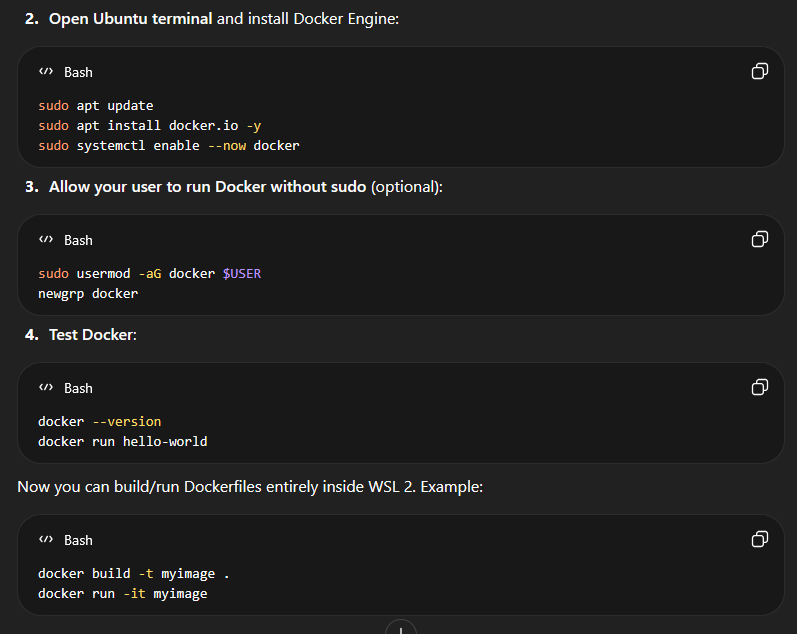

In [106]:
df.to_csv("E:\Openclassrooms\AI Engineer\P7\data.csv")

In [110]:
df = pd.read_csv("data.csv")

In [ ]:
self quering

chunking

paren chunking

ragas

In [111]:
df

,Unnamed: 0,uid,title.fr,description.fr,location.name,location.city,firstTiming.begin,firstTiming.end,nextTiming.begin,nextTiming.end,lastTiming.begin,embeddings
0,0,80262476,HOLLIE COOK + LA YEGROS + SISKA,"Dub, Reggae",La Sirène,La Rochelle,2026-04-03 18:00:00+00:00,2026-04-03 23:00:00+00:00,2026-04-03 18:00:00+00:00,2026-04-03 23:00:00+00:00,2026-04-03 18:00:00+00:00,[ 1.56426337e-02 -1.52937593e-02 -2.52250023e-...
1,1,56513581,FOREVER PAVOT + YIN YIN,"Pop, Psyché, Rock",La Sirène,La Rochelle,2026-04-09 18:00:00+00:00,2026-04-09 23:00:00+00:00,2026-04-09 18:00:00+00:00,2026-04-09 23:00:00+00:00,2026-04-09 18:00:00+00:00,[ 3.49872652e-03 -4.94991988e-03 -2.43420489e-...
2,2,22276968,HEAVY LUNGS + BODY HORROR + CHEST.,"Indie, Post-Punk",La Sirène,La Rochelle,2026-04-11 18:00:00+00:00,2026-04-11 23:00:00+00:00,2026-04-11 18:00:00+00:00,2026-04-11 23:00:00+00:00,2026-04-11 18:00:00+00:00,[-5.56474086e-03 7.89207872e-03 -1.74335893e-...
3,3,88012351,BLU SAMU + ADÉS THE PLANET,"Chanson, Rap",La Sirène,La Rochelle,2026-04-24 18:00:00+00:00,2026-04-24 23:00:00+00:00,2026-04-24 18:00:00+00:00,2026-04-24 23:00:00+00:00,2026-04-24 18:00:00+00:00,[ 2.15230733e-02 5.68094738e-02 9.58490744e-...
4,4,84445,BLACK SEA DAHU + MEL D,"Folk, Pop",La Sirène,La Rochelle,2026-04-30 18:00:00+00:00,2026-04-30 23:00:00+00:00,2026-04-30 18:00:00+00:00,2026-04-30 23:00:00+00:00,2026-04-30 18:00:00+00:00,[-3.51615972e-03 -9.43527278e-03 2.11695163e-...
...,...,...,...,...,...,...,...,...,...,...,...,...
94,94,96654035,IDLES,"Post-Punk, Rock",La Sirène,La Rochelle,2025-06-04 18:00:00+00:00,2025-06-05 00:00:00+00:00,NaN,NaN,NaN,[ 2.04343395e-03 -5.56761678e-03 -1.39250178e-...
95,95,86219516,YOUSSOUPHA + JOANNE RADAO + BASE,"Chanson, Rap",La Sirène,La Rochelle,2025-05-23 18:00:00+00:00,2025-05-23 23:00:00+00:00,NaN,NaN,NaN,[ 2.15230733e-02 5.68094738e-02 9.58490744e-...
96,96,42832059,COILGUNS + GOING OFF + TREAKS,"Hardcore, Noise, Rock",La Sirène,La Rochelle,2025-05-20 18:00:00+00:00,2025-05-20 23:00:00+00:00,NaN,NaN,NaN,[ 4.92769352e-04 -1.20393420e-02 -5.91836218e-...
97,97,78028280,L'ODYSSÉE MUSICALE DES 40 ANS !,L'ASSOCIATION DE L'ÉCOLE DE MUSIQUE DE PÉRIGNY...,La Sirène,La Rochelle,2025-05-17 16:00:00+00:00,2025-05-17 21:59:00+00:00,NaN,NaN,NaN,[-8.73681344e-03 1.48183135e-02 1.29992561e-...


In [50]:
chain = (
    prompt
    | llm
    | StrOutputParser()
)


response = chain.invoke({
    "context": context,
    "question": question
})

print(response)

Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Both `max_new_tokens` (=300) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Tu es un assistant qui recommande des événements.

Contexte:

    Titre: DISIZ + BÉESAU
    Description: Pop
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: ODEZENNE présente "GRAND PRIX SURPRISE-PARTIE"
    Description: Chanson, Electro, Hip-Hop
    Ville: La Rochelle
    Lieu: La Sirène
    Date: 2026-07-11 17:00:00+00:00
    


    Titre: SUZANE + ANDREA PEMBAD'YS
    Description: Chanson, Pop
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: SHOWQUAI’S DE RENTRÉE DES STUDIOS
    Description: Pop, Électro
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: KOMPROMAT + DOUBLE VITRAGE + NOMENKLATÜR + IPPON + TEDAAK + AFTER CLUB
    Description: Electro
    Ville: La Rochelle
    Lieu: La Sirène
    Date: NaT
    


    Titre: FFF + 1ÈRE PARTIE
    Description: Funk, Rock
    Ville: La Rochelle
    Lieu: La Sirène
    Date: 2026-10-02 18:00:00+00:00
    


    Titre: BLU SAMU + ADÉS THE PLANET
    Description: 

In [42]:
df[df["description.fr"]== 'L\'ASSOCIATION DE L\'ÉCOLE DE MUSIQUE DE PÉRIGNY FÊTE']

,uid,title.fr,description.fr,location.name,location.city,firstTiming.begin,firstTiming.end,nextTiming.begin,nextTiming.end,lastTiming.begin,embeddings
87,78028280,L'ODYSSÉE MUSICALE DES 40 ANS !,L'ASSOCIATION DE L'ÉCOLE DE MUSIQUE DE PÉRIGNY...,La Sirène,La Rochelle,2025-05-17 16:00:00+00:00,2025-05-17 21:59:00+00:00,NaT,NaT,NaT,"[-0.008736847, 0.014818321, 0.012999263, 0.071..."


In [41]:
df

,uid,title.fr,description.fr,location.name,location.city,firstTiming.begin,firstTiming.end,nextTiming.begin,nextTiming.end,lastTiming.begin,embeddings
0,74935765,MOSIMANN (LIVE) + GRAND BLEU + BEFORE & AFTER ...,Electro,La Sirène,La Rochelle,2026-03-18 19:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-18 19:00:00+00:00,2026-03-19 00:00:00+00:00,2026-03-18 19:00:00+00:00,"[0.018178456, -0.030583283, -0.011888005, 0.00..."
1,5526989,MOSIMANN (LIVE) + GRAND BLEU + BEFORE & AFTER ...,Electro,La Sirène,La Rochelle,2026-03-19 19:00:00+00:00,2026-03-20 00:00:00+00:00,2026-03-19 19:00:00+00:00,2026-03-20 00:00:00+00:00,2026-03-19 19:00:00+00:00,"[0.018178456, -0.030583283, -0.011888005, 0.00..."
2,39192000,YUSTON XIII + SKABE,"Hip-Hop, Rap",La Sirène,La Rochelle,2026-03-20 19:00:00+00:00,2026-03-21 00:00:00+00:00,2026-03-20 19:00:00+00:00,2026-03-21 00:00:00+00:00,2026-03-20 19:00:00+00:00,"[0.0061929473, -0.011191967, -0.014611359, -0...."
3,33869704,STEPH STRINGS + 1ÈRE PARTIE,Folk,La Sirène,La Rochelle,2026-03-31 18:00:00+00:00,2026-03-31 23:00:00+00:00,2026-03-31 18:00:00+00:00,2026-03-31 23:00:00+00:00,2026-03-31 18:00:00+00:00,"[0.010645327, 0.062435865, 0.0064957845, -0.01..."
4,80262476,HOLLIE COOK + LA YEGROS + SISKA,"Dub, Reggae",La Sirène,La Rochelle,2026-04-03 18:00:00+00:00,2026-04-03 23:00:00+00:00,2026-04-03 18:00:00+00:00,2026-04-03 23:00:00+00:00,2026-04-03 18:00:00+00:00,"[0.015642634, -0.015293759, -0.025225002, -0.0..."
...,...,...,...,...,...,...,...,...,...,...,...
84,96654035,IDLES,"Post-Punk, Rock",La Sirène,La Rochelle,2025-06-04 18:00:00+00:00,2025-06-05 00:00:00+00:00,NaT,NaT,NaT,"[0.002043434, -0.005567617, -0.013925018, -0.0..."
85,86219516,YOUSSOUPHA + JOANNE RADAO + BASE,"Chanson, Rap",La Sirène,La Rochelle,2025-05-23 18:00:00+00:00,2025-05-23 23:00:00+00:00,NaT,NaT,NaT,"[0.021523073, 0.056809474, 0.009584907, -0.024..."
86,42832059,COILGUNS + GOING OFF + TREAKS,"Hardcore, Noise, Rock",La Sirène,La Rochelle,2025-05-20 18:00:00+00:00,2025-05-20 23:00:00+00:00,NaT,NaT,NaT,"[0.00049277645, -0.0120393075, -0.0059183505, ..."
87,78028280,L'ODYSSÉE MUSICALE DES 40 ANS !,L'ASSOCIATION DE L'ÉCOLE DE MUSIQUE DE PÉRIGNY...,La Sirène,La Rochelle,2025-05-17 16:00:00+00:00,2025-05-17 21:59:00+00:00,NaT,NaT,NaT,"[-0.008736847, 0.014818321, 0.012999263, 0.071..."


In [32]:
print("Nombre d'événements après filtre :", len(df_search))
print(df_search["firstTiming.begin"].head())

Nombre d'événements après filtre : 89
0   2026-03-18 19:00:00+00:00
1   2026-03-19 19:00:00+00:00
2   2026-03-20 19:00:00+00:00
3   2026-03-31 18:00:00+00:00
4   2026-04-03 18:00:00+00:00
Name: firstTiming.begin, dtype: datetime64[us, UTC]


In [33]:
print(df["firstTiming.begin"].dtype)

datetime64[us, UTC]


In [ ]:
firstTiming.begin	firstTiming.end	nextTiming.begin	nextTiming.end	lastTiming.begin

In [26]:
q1 = model.encode(["concert"], convert_to_numpy=True)
q2 = model.encode(["football"], convert_to_numpy=True)

print(q1[:5])
print(q2[:5])

[[-6.44183531e-02  8.84363055e-03  1.50777894e-04  7.38923699e-02
  -3.14690396e-02 -1.21804737e-02 -1.64285433e-02 -9.44752712e-03
  -2.56562196e-02  5.44699430e-02 -1.85540412e-02 -2.60871649e-02
  -1.50851598e-02  2.88831051e-02  6.49566725e-02 -8.64847228e-02
   1.75555386e-02 -1.69787165e-02 -7.74959056e-03 -3.67946480e-03
  -6.93652332e-02  2.01296825e-02 -3.96425426e-02 -4.38384991e-03
  -2.42330926e-03 -2.79069450e-02 -3.26944888e-02 -1.19475303e-02
  -1.04911812e-02  8.36679488e-02 -2.01856941e-02 -8.40246528e-02
   4.22297493e-02 -1.82419010e-02  1.76736830e-06  3.70037206e-03
   4.35340498e-03 -1.49607435e-02  5.20426556e-02 -3.10590025e-02
  -7.32462481e-02  5.31302430e-02 -7.64783770e-02  3.76476571e-02
   6.62168488e-03 -5.81817478e-02 -2.28554197e-03 -4.28036191e-02
  -4.77474965e-02  3.04949079e-02  2.52655149e-02 -3.00973207e-02
  -2.36305911e-02 -8.68438650e-03 -1.23503776e-02  4.84013632e-02
  -2.64327172e-02 -5.73340245e-02 -2.33006086e-02 -5.88191338e-02
   3.57660

In [27]:
print(len(df['embeddings']))
print(df['embeddings'].iloc[0][:5])
print(df['embeddings'].iloc[1][:5])
print(df['embeddings'].iloc[2][:5])

89
[ 0.01817846 -0.03058328 -0.011888    0.00570772  0.03162103]
[ 0.01817846 -0.03058328 -0.011888    0.00570772  0.03162103]
[ 0.00619295 -0.01119197 -0.01461136 -0.07014152  0.03787778]


In [28]:
print(np.allclose(df['embeddings'].iloc[0], df['embeddings'].iloc[1]))

True


In [29]:
print(similarities[0][:10])

[0.18534714 0.18534714 0.15637353 0.0501688  0.17653853 0.2389457
 0.16716565 0.17017472 0.09114122 0.20534599]


In [30]:
top_idx = np.argsort(similarities[0])[-5:][::-1]

for i in top_idx:
    print(similarities[0][i], df.iloc[i]['description.fr'])

0.6165443 L'ASSOCIATION DE L'ÉCOLE DE MUSIQUE DE PÉRIGNY FÊTE
0.43801343 Danse, Electro
0.34007818 Jazz, Jeune Public
0.30378926 Néo-Classique, Piano
0.3030277 Baroque, Folk


In [1]:
model = "mistralai/Mistral-7B-Instruct-v0.1"  # Exemple, vérifier si embeddings disponibles
tokenizer = AutoTokenizer.from_pretrained(model)
model = AutoModel.from_pretrained(model, device_map="auto")

def get_embeddings(texts, max_length=512):
    inputs = tokenizer(texts, return_tensors="pt", padding=True, truncation=True, max_length=max_length)
    with torch.no_grad():
        outputs = model(**inputs)
    # On prend la moyenne des hidden states du dernier layer pour créer l'embedding
    embeddings = outputs.last_hidden_state.mean(dim=1)
    return embeddings.cpu().numpy()

NameError: name 'AutoTokenizer' is not defined

In [23]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.5.1+cu121
True


In [ ]:
import torch
import transformers

print(torch.__version__)
print(transformers.__version__)

from transformers import AutoModel
model = AutoModel.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1", device_map="auto")

2.10.0+cpu
5.3.0


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.


In [ ]:
embeddings = get_embeddings(descriptions)
print(embeddings.shape)
# (nombre d'événements, taille du vecteur)

In [ ]:
df["embedding"] = list(embeddings)
print(df.head())

In [1]:
import torch
import transformers
import sentence_transformers

print(torch.__version__)                 # ex: 2.5.1+cu121
print(transformers.__version__)          # >= 4.33 recommandé
print(sentence_transformers.__version__) # >= 2.2.2 recommandé

e:\Apps\python 3.11\openagenda-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2.10.0+cpu
5.3.0
5.2.3
